In [125]:
import pandas as pd
import pathlib
import os, os.path

In [126]:
dir_cur = pathlib.Path(os.getcwd())
input_data = dir_cur.joinpath("input_data")
output_data = dir_cur.joinpath("output_data")

# Census Households counts (2014) by Region, District and Mid-Year Projected Households (2015-2021) 

In [127]:
# Load the house data
house = pd.read_csv(input_data.joinpath("households.csv")) 
house.tail()

,year,households
5,2020,8975900.0
6,2021,9813500.0
7,2022,NaN
8,2023,NaN
9,2024,10698913.0


In [128]:

house['households'] = house['households'].interpolate(method='linear')
house.tail()

,year,households
5,2020,8.975900e+06
6,2021,9.813500e+06
7,2022,1.010864e+07
8,2023,1.040378e+07
9,2024,1.069891e+07


In [129]:
pop = pd.read_csv(output_data.joinpath("POPULATION.csv")) 
pop.tail()

,year,population_gnrl_rural,population_gnrl_urban
146,2096,12713596,84795595
147,2097,11720392,85972447
148,2098,10722328,87144700
149,2099,9720409,88318504
150,2100,8714035,89486907


In [130]:
# Merge the population and household data on 'year'
df = pd.merge(pop, house, on='year', how='left')
df.head()

,year,population_gnrl_rural,population_gnrl_urban,households
0,1950,5259623,155176,NaN
1,1951,5398130,167554,NaN
2,1952,5541329,180536,NaN
3,1953,5690012,194173,NaN
4,1954,5844177,208492,NaN


In [131]:
# Calculate the population growth rate
df['population'] = df['population_gnrl_rural'] + df['population_gnrl_urban']
df['pop_growth'] = df['population'] / df['population'].shift(1)

In [132]:
# Find the indices for the first and last years with observed household data
first_obs_idx = df[df['households'].notnull()].index[0]
last_obs_idx = df[df['households'].notnull()].index[-1]

In [133]:
# Forward extrapolation (for years after the last observed household data)
for idx in range(last_obs_idx + 1, len(df)):
    prev_idx = idx - 1
    df.at[idx, 'households'] = df.at[prev_idx, 'households'] * df.at[idx, 'pop_growth']

In [134]:
# Backward extrapolation (for years before the first observed household data)
for idx in range(first_obs_idx - 1, -1, -1):
    next_idx = idx + 1
    df.at[idx, 'households'] = df.at[next_idx, 'households'] / df.at[next_idx, 'pop_growth']


In [135]:
# Round to integer values and set as integer type
df['households'] = df['households'].round().astype('Int64')

<Axes: xlabel='year'>

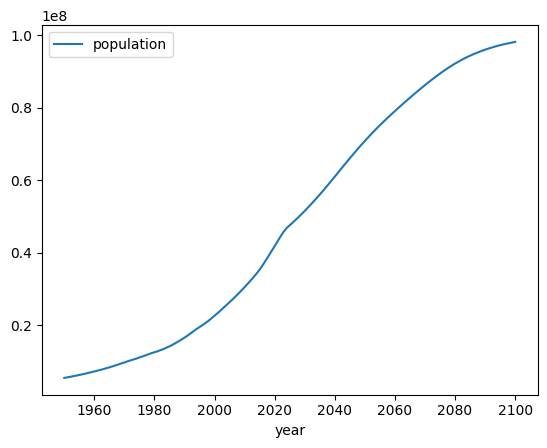

In [136]:
df.plot(x = 'year', y='population')

<Axes: xlabel='year'>

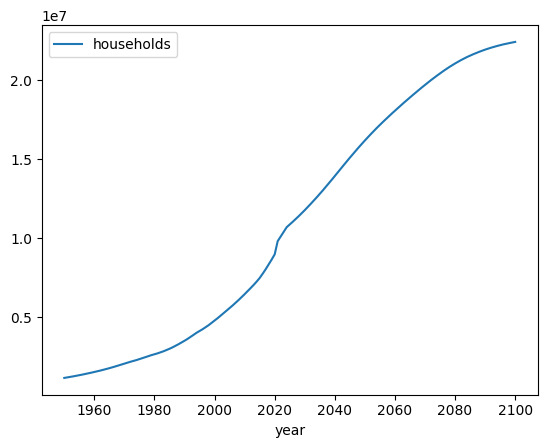

In [137]:
df.plot(x = 'year', y='households')

<Axes: xlabel='year'>

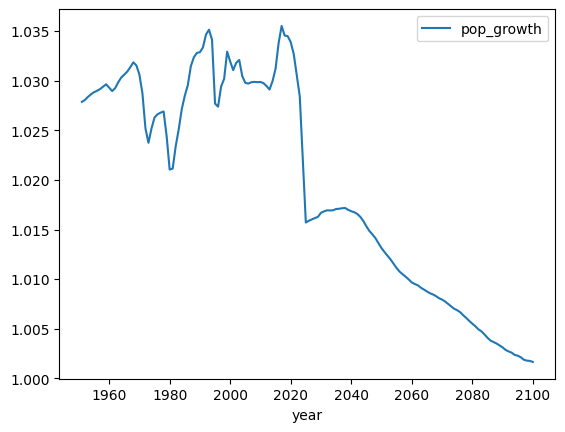

In [138]:
df.plot(x = 'year', y='pop_growth')

In [139]:
df['occrateinit_gnrl_occupancy'] = df['population'] / df['households']
df.describe()

,year,population_gnrl_rural,population_gnrl_urban,households,population,pop_growth,occrateinit_gnrl_occupancy
count,151.000000,1.510000e+02,1.510000e+02,151.0,1.510000e+02,150.000000,151.0
mean,2025.000000,2.332505e+07,2.535029e+07,10983509.298013,4.867534e+07,1.019564,4.540584
std,43.734045,1.137344e+07,2.769305e+07,7602697.06197,3.279821e+07,0.010838,0.173613
min,1950.000000,5.259623e+06,1.551760e+05,1145649.0,5.414799e+06,1.001653,4.376671
25%,1987.500000,1.237665e+07,1.569422e+06,3229683.5,1.526479e+07,1.009197,4.376671
50%,2025.000000,2.355167e+07,1.353908e+07,10866931.0,4.756098e+07,1.017156,4.376671
75%,2062.500000,3.470930e+07,4.492061e+07,18504487.0,8.098805e+07,1.029742,4.726405
max,2100.000000,3.907048e+07,8.948691e+07,22437361.0,9.820094e+07,1.035522,4.726407


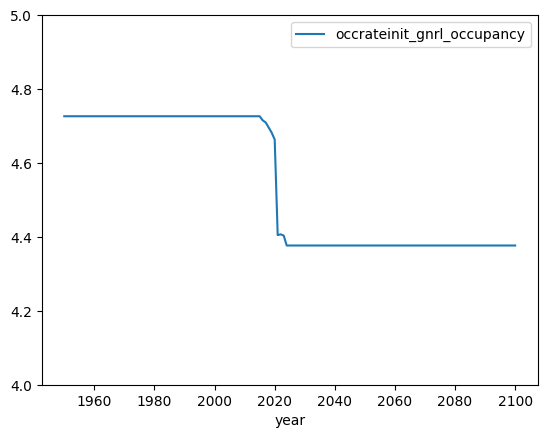

In [140]:
import matplotlib.pyplot as plt

ax = df.plot(x='year', y='occrateinit_gnrl_occupancy')
plt.ylim(4, 5)  # Ajusta los valores mínimo y máximo del eje y
plt.show()

In [72]:
# Prepare the final DataFrame with the required columns
df = df[['year', 'occrateinit_gnrl_occupancy']]

In [73]:
df.to_csv(output_data.joinpath("occrateinit_gnrl_occupancy.csv"), index=False)